In [1]:
import pandas as pd

**Data Import and Cleaning:**

 - Import the dataset using Pandas.

In [2]:
data = pd.read_csv('global_power_plant_database.csv')
data.head()

<ipython-input-2-77657553f303>:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('global_power_plant_database.csv')


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


- Identify missing values and handle them appropriately.
- Use NumPy to convert relevant columns to numerical types if necessary.



In [3]:
total_rows = len(data)
total_rows

34936

In [4]:
data.duplicated().sum()

0

--> No duplicated data to remove

In [5]:
data.isnull().sum()

,0
country,0
country_long,0
name,0
gppd_idnr,0
capacity_mw,0
latitude,0
longitude,0
primary_fuel,0
other_fuel1,32992
other_fuel2,34660


In [6]:
# Find percentage of missing values
missing_percent = (data.isnull().sum() / len(data)) * 100

# Display columns with more than 50% missing values
print(missing_percent[missing_percent > 50])

other_fuel1                      94.435539
other_fuel2                      99.209984
other_fuel3                      99.736661
commissioning_year               50.060110
wepp_id                          53.532173
year_of_capacity_data            57.387795
generation_gwh_2013              81.632127
generation_gwh_2014              79.316464
generation_gwh_2015              76.519922
generation_gwh_2016              73.826425
generation_gwh_2017              72.807419
generation_gwh_2018              72.415274
generation_gwh_2019              72.352301
generation_data_source           67.368903
estimated_generation_gwh_2013    53.858484
estimated_generation_gwh_2014    52.762194
estimated_generation_gwh_2015    51.196474
dtype: float64


In [7]:
# For columns 'source' , 'url' and 'geolocation_source' there are only few rows with missing values
# upon a 34936 total_rows
# We can remove this rows
df_cleaned = data.dropna(subset=['source', 'url', 'geolocation_source']).copy()

# Drop colomns with too many missing values
df_cleaned.drop(columns=['other_fuel1', 'other_fuel2', 'other_fuel3',
                'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015',
                'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018',
                'generation_gwh_2019',
                'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014',
                'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016'], inplace=True)

# Fill categorical missing values with "Unknown"
df_cleaned = df_cleaned.assign(
    owner=df_cleaned['owner'].fillna("Unknown"),
    wepp_id=df_cleaned['wepp_id'].astype(str).fillna("Unknown"),
    year_of_capacity_data=df_cleaned['year_of_capacity_data'].astype(str).fillna("Unknown"),
    generation_data_source=df_cleaned['generation_data_source'].astype(str).fillna("Unknown")
)
# Fill numerical missing values appropriately
df_cleaned = df_cleaned.assign(
    commissioning_year=df_cleaned['commissioning_year'].fillna(df_cleaned['commissioning_year'].mean()),
    estimated_generation_gwh_2017=df_cleaned['estimated_generation_gwh_2017'].fillna(df_cleaned['estimated_generation_gwh_2017'].median())
)

df_cleaned.isnull().sum()

,0
country,0
country_long,0
name,0
gppd_idnr,0
capacity_mw,0
latitude,0
longitude,0
primary_fuel,0
commissioning_year,0
owner,0


**Exploratory Data Analysis:**

 - Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns.


In [8]:
df_cleaned.describe()

,capacity_mw,latitude,longitude,commissioning_year,estimated_generation_gwh_2017
count,34499.000000,34499.000000,34499.000000,34499.000000,34499.000000
mean,156.748890,32.795941,-8.386190,1997.413755,657.521771
std,457.995421,22.763567,77.833691,16.604911,2321.029976
min,1.000000,-77.847000,-179.977700,1896.000000,0.000000
25%,4.800000,29.286000,-77.974750,1997.413755,8.790000
50%,16.000000,39.784400,-2.424000,1997.413755,36.700000
75%,72.850000,46.364450,40.236350,2007.000000,184.990000
max,13050.000000,71.292000,179.388700,2020.000000,65600.320000


- Explore the distribution of power plants by country and fuel type.

In [9]:
# Power plants by country
df_cleaned['country'].value_counts()

,count
country,
USA,9833
CHN,3818
GBR,2735
BRA,2360
FRA,2155
...,...
LSO,1
ESH,1
SUR,1


In [10]:
# Power plants by fuel type
df_cleaned['primary_fuel'].value_counts()

,count
primary_fuel,
Solar,10555
Hydro,6992
Wind,5276
Gas,3920
Coal,2329
Oil,2315
Biomass,1430
Waste,1068
Geothermal,189


In [11]:
df_cleaned.groupby(['country', 'primary_fuel']).size().unstack()

primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wave and Tidal,Wind
country,,,,,,,,,,,,,,,
AFG,NaN,NaN,NaN,1.0,NaN,6.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
AGO,NaN,NaN,NaN,3.0,NaN,5.0,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ALB,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
ARE,NaN,NaN,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN
ARG,NaN,9.0,NaN,57.0,NaN,50.0,3.0,96.0,2.0,NaN,7.0,NaN,NaN,NaN,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VNM,2.0,24.0,NaN,9.0,NaN,174.0,NaN,6.0,NaN,NaN,16.0,NaN,NaN,NaN,5.0
YEM,NaN,NaN,NaN,1.0,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZAF,2.0,17.0,NaN,2.0,NaN,6.0,1.0,2.0,NaN,NaN,44.0,NaN,6.0,NaN,24.0


**Statistical Analysis:**

- Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions.
   - power output : 'capacity_mv'
   - fuel type : 'primary_fuel'

In [12]:
fuel_stats = df_cleaned.groupby('primary_fuel')['capacity_mw'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
fuel_stats


,mean,median,std,min,max,count
primary_fuel,,,,,,
Biomass,23.972938,9.45000,39.461805,1.0,528.00,1430
Coal,843.843280,600.00000,888.286866,1.2,7000.00,2329
Cogeneration,98.731707,31.90000,283.428252,1.6,1404.00,41
Gas,364.761761,140.00000,559.779412,1.0,8865.00,3920
Geothermal,67.130952,30.00000,114.640890,1.0,1163.00,189
Hydro,123.358713,19.22500,412.716977,1.0,13050.00,6992
Nuclear,2056.650870,1849.20000,1290.300184,48.0,8212.00,184
Oil,112.548471,9.00000,392.362367,1.0,6794.00,2315
Other,84.020000,40.00000,145.891392,4.5,845.26,43


In [13]:
highest_avg_fuel = fuel_stats["mean"].idxmax()
lowest_avg_fuel = fuel_stats["mean"].idxmin()

print(f"Fuel type with the highest average capacity: {highest_avg_fuel}")
print(f"Fuel type with the lowest average capacity: {lowest_avg_fuel}")


Fuel type with the highest average capacity: Nuclear
Fuel type with the lowest average capacity: Storage


- Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.

In [14]:
from scipy import stats
# Ho = no difference
# H1 = difference in the capacity

fuel_types = df_cleaned['primary_fuel'].unique()
capacity_by_fuel = [df_cleaned[df_cleaned['primary_fuel'] == fuel]['capacity_mw'] for fuel in fuel_types]

# ANOVA test
f_stat, p_value = stats.f_oneway(*capacity_by_fuel)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
  print("Reject the null hypothesis. There is a significant difference in the mean capacity between fuel types.")
else:
  print("Fail to reject the null hypothesis. There is no significant difference in the mean capacity between fuel types.")

F-statistic: 1122.03
P-value: 0.00000
Reject the null hypothesis. There is a significant difference in the mean capacity between fuel types.


**Time Series Analysis:**

- If the dataset includes time-related data (like year of establishment), use NumPy to analyze trends over time.

In [15]:
df_cleaned["commissioning_year"] = pd.to_numeric(df_cleaned["commissioning_year"], errors='coerce')


In [16]:
import matplotlib.pyplot as plt
import numpy as np

yearly_counts = df_cleaned["commissioning_year"].value_counts().sort_index()
print("Number of power plants build per year", yearly_counts)

years = yearly_counts.index.to_numpy()
counts = yearly_counts.values

window = 5
moving_avg = np.convolve(counts, np.ones(window)/window, mode='valid')
print("5-year moving average of power plant constuction", moving_avg)

Number of power plants build per year commissioning_year
1896.000000      1
1899.000000      1
1900.000000      6
1901.000000      2
1902.000000      4
              ... 
2019.000000    596
2019.000000      1
2019.411765      1
2019.796326      1
2020.000000    150
Name: count, Length: 2024, dtype: int64
5-year moving average of power plant constuction [  2.8   3.4   3.4 ... 120.  120.  149.8]


- Explore how the mix of fuel types for power generation has evolved over the years

In [17]:
# Evolution of fuel types over time
fuel_by_year = df_cleaned.groupby(['commissioning_year', 'primary_fuel']).size().unstack().fillna(0)
print(fuel_by_year.head())

primary_fuel        Biomass  Coal  Cogeneration  Gas  Geothermal  Hydro  \
commissioning_year                                                        
1896.0                  0.0   0.0           0.0  0.0         0.0    1.0   
1899.0                  0.0   0.0           0.0  0.0         0.0    1.0   
1900.0                  0.0   0.0           0.0  1.0         0.0    3.0   
1901.0                  0.0   0.0           0.0  0.0         0.0    2.0   
1902.0                  0.0   0.0           0.0  0.0         0.0    4.0   

primary_fuel        Nuclear  Oil  Other  Petcoke  Solar  Storage  Waste  \
commissioning_year                                                        
1896.0                  0.0  0.0    0.0      0.0    0.0      0.0    0.0   
1899.0                  0.0  0.0    0.0      0.0    0.0      0.0    0.0   
1900.0                  0.0  2.0    0.0      0.0    0.0      0.0    0.0   
1901.0                  0.0  0.0    0.0      0.0    0.0      0.0    0.0   
1902.0                  

**Advanced Visualization:**

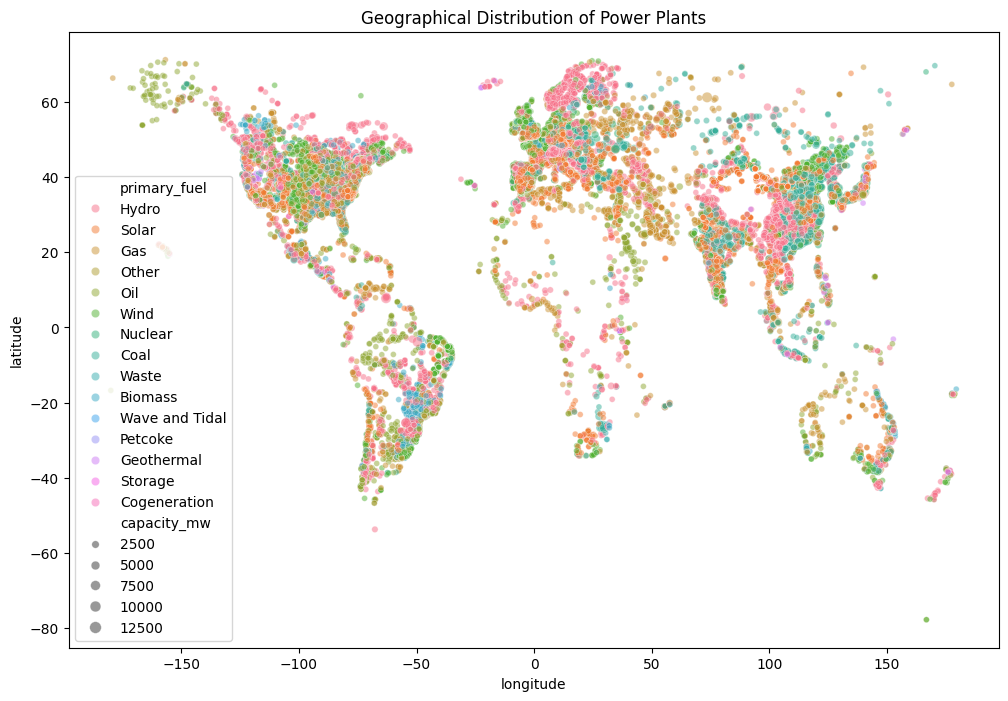

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='longitude', y='latitude', size='capacity_mw', hue='primary_fuel', data=df_cleaned, alpha=0.5)
plt.title('Geographical Distribution of Power Plants')
plt.show()

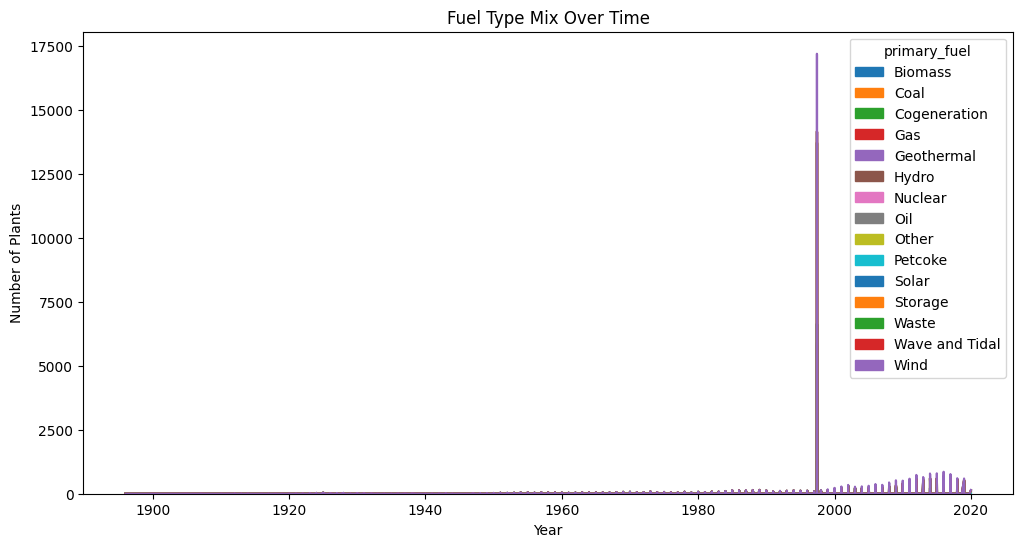

In [19]:
fuel_by_year.plot(kind='area', stacked=True, figsize=(12, 6))
plt.title('Fuel Type Mix Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Plants')
plt.show()

**Matrix Operations in Real-World Context:**

In [20]:
# Pivot table as a matrix
matrix = pd.pivot_table(df_cleaned, values='capacity_mw', index='primary_fuel', columns='country', aggfunc='sum').fillna(0)
matrix_np = matrix.to_numpy()

# Compute covariance matrix
cov_matrix = np.cov(matrix_np)
print("Covariance Matrix:\n", cov_matrix)

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Covariance Matrix:
 [[ 1.24575038e+06  7.87232505e+06  5.58314113e+04  1.75929366e+07
   1.08945558e+05  1.19042949e+07  3.91057584e+06  1.65451740e+06
   3.62378600e+04  7.00326239e+04  1.48375511e+06  3.16089727e+04
   3.26929957e+05  1.32311590e+03  4.30667761e+06]
 [ 7.87232505e+06  6.07471063e+09  1.49545519e+06  8.45819976e+08
   5.70714934e+06  5.85264336e+08  1.96145904e+08  5.53342902e+07
   8.94450506e+05  3.37447020e+06  3.82302045e+08  1.16791975e+06
   1.42938537e+07  2.06727213e+04  3.77512568e+08]
 [ 5.58314113e+04  1.49545519e+06  6.03836049e+04  3.64580365e+06
   2.25602495e+04  6.21990499e+05  7.60515588e+05  2.01850946e+05
   3.06546268e+03  1.44699795e+04  3.68331063e+05  2.11074100e+04
   9.33095713e+04  6.11109256e+02  1.03833864e+06]
 [ 1.75929366e+07  8.45819976e+08  3.64580365e+06  1.89837845e+09
   1.29024366e+07  3.76097980e+08  3.70448623e+08  1.45054552e+08
   2.03709171e+06  7.64995295e+06  1.28683483e+08  2.72310604e+06
   3.20243921e+07  3.48161364e+04  

In [21]:
# Filter plants with capacity > 75th percentile
high_capacity = df_cleaned[df_cleaned['capacity_mw'] > np.percentile(df_cleaned['capacity_mw'].dropna(), 75)]
print(high_capacity['primary_fuel'].value_counts())

primary_fuel
Gas               2413
Coal              2068
Hydro             1894
Wind               903
Solar              489
Oil                439
Nuclear            183
Biomass            127
Geothermal          52
Waste               29
Other               15
Cogeneration         6
Petcoke              4
Wave and Tidal       2
Storage              1
Name: count, dtype: int64


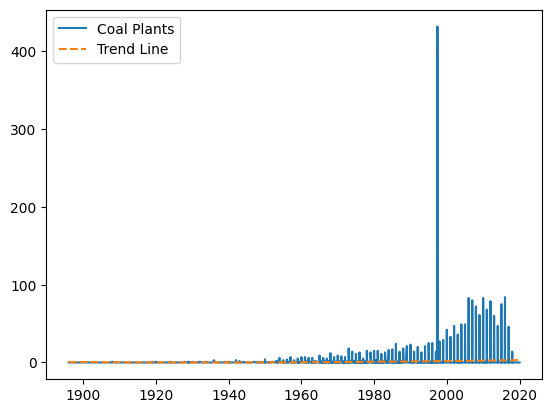

In [22]:
# Use NumPy to compute a smoothed trend line
x = fuel_by_year.index.to_numpy()
y = fuel_by_year['Coal'].to_numpy()
coeffs = np.polyfit(x, y, 2)  # 4rd-degree polynomial
trend = np.polyval(coeffs, x)

plt.plot(x, y, label='Coal Plants')
plt.plot(x, trend, '--', label='Trend Line')
plt.legend()
plt.show()